# Implementacao Completa: Classificacao Binaria (2 Classes)

Este notebook segue o template de classificacao e aplica um fluxo completo para o dataset binario do projeto.

Objetivos deste notebook:
- Carregar o arquivo final `../data/data_set_final.csv` da versao binaria.
- Realizar analise exploratoria (EDA) com graficos para entender distribuicoes e relacoes.
- Preparar os dados sem alterar os valores finais do dataset.
- Treinar um modelo binario com 2 classes e avaliar acuracia e metricas por classe.

Mapeamento da classe alvo (`CLASSI_FIN`):
- 0 = OUTRAS_DOENCAS
- 1 = DENGUE


In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping

# Configuracoes visuais e de logs para facilitar analise.
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
gpu = tf.config.experimental.list_physical_devices('GPU')

print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Visible GPUs:", gpu)

I0000 00:00:1779564931.863973   11505 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779564931.219320   11505 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779564932.518850   11505 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
Built with CUDA: True
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1779564933.643230   11505 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## STEP 1: Load Data (Dataset Final)

In [2]:
# Caminho oficial do dataset final gerado pelo script de codificacao.
DATA_PATH = "../data/data_set_final.csv"
TARGET_COL = "CLASSI_FIN"
CLASS_NAME_MAP = {0: "OUTRAS_DOENCAS", 1: "DENGUE"}

df = pd.read_csv(DATA_PATH)

# Garantimos que a coluna alvo seja numerica para treino binario.
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="raise").astype(int)

print("Dataset carregado com sucesso:", DATA_PATH)
print("Shape:", df.shape)
print("Colunas:", len(df.columns))
df.head()

Dataset carregado com sucesso: ../data/data_set_final.csv
Shape: (11448, 27)
Colunas: 27


,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ZONA,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,...,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DIAS,CLASSI_FIN
0,4003.0,1,6.0,9.0,9.0,1.0,1.0,2.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,5,1
1,4043.0,0,9.0,9.0,1.0,1.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,19,1
2,4039.0,0,5.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,7,1
3,4008.0,1,6.0,9.0,9.0,1.0,2.0,1.0,1.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3,1
4,4014.0,1,6.0,9.0,9.0,1.0,1.0,1.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0,1


## STEP 2: Data Inspection and Quality Checks

In [3]:
# Inspecao estrutural para validar se os dados finais estao prontos para modelagem.
print("Tipos de dados:")
print(df.dtypes)

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

print("\nDistribuicao da classe alvo (codigo):")
print(df[TARGET_COL].value_counts().sort_index())

# Estatisticas descritivas das variaveis numericas.
df.describe().T.head(10)

Tipos de dados:
NU_IDADE_N    float64
CS_SEXO         int64
CS_GESTANT    float64
CS_RACA       float64
CS_ZONA       float64
FEBRE         float64
MIALGIA       float64
CEFALEIA      float64
EXANTEMA      float64
VOMITO        float64
NAUSEA        float64
DOR_COSTAS    float64
CONJUNTVIT    float64
ARTRITE       float64
ARTRALGIA     float64
PETEQUIA_N    float64
LACO          float64
DOR_RETRO     float64
DIABETES      float64
HEMATOLOG     float64
HEPATOPAT     float64
RENAL         float64
HIPERTENSA    float64
ACIDO_PEPT    float64
AUTO_IMUNE    float64
DIAS            int64
CLASSI_FIN      int64
dtype: object

Valores ausentes por coluna:
NU_IDADE_N    0
CS_SEXO       0
CS_GESTANT    0
CS_RACA       0
CS_ZONA       0
FEBRE         0
MIALGIA       0
CEFALEIA      0
EXANTEMA      0
VOMITO        0
NAUSEA        0
DOR_COSTAS    0
CONJUNTVIT    0
ARTRITE       0
ARTRALGIA     0
PETEQUIA_N    0
LACO          0
DOR_RETRO     0
DIABETES      0
HEMATOLOG     0
HEPATOPAT     0
RENAL     

,count,mean,std,min,25%,50%,75%,max
NU_IDADE_N,11448.0,3990.885045,243.281548,39.0,4014.0,4028.0,4044.0,4400.0
CS_SEXO,11448.0,0.446104,0.500611,0.0,0.0,0.0,1.0,2.0
CS_GESTANT,11448.0,6.244147,1.396329,0.0,6.0,6.0,6.0,9.0
CS_RACA,11448.0,6.569619,2.760599,0.0,4.0,9.0,9.0,9.0
CS_ZONA,11448.0,2.278477,2.913658,1.0,1.0,1.0,1.0,9.0
FEBRE,11448.0,1.183526,0.387114,1.0,1.0,1.0,1.0,2.0
MIALGIA,11448.0,1.417802,0.493219,1.0,1.0,1.0,2.0,2.0
CEFALEIA,11448.0,1.380678,0.485575,1.0,1.0,1.0,2.0,2.0
EXANTEMA,11448.0,1.759085,0.427658,1.0,2.0,2.0,2.0,2.0
VOMITO,11448.0,1.797345,0.401995,1.0,2.0,2.0,2.0,2.0


## STEP 3: Visualize Target Distribution

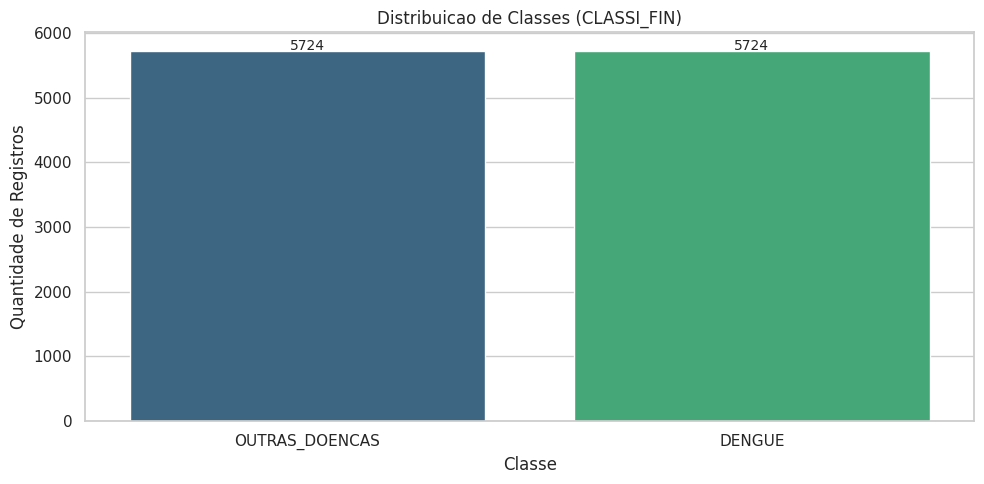

In [4]:
# Grafico da distribuicao das classes para confirmar o balanceamento do dataset.
class_counts = df[TARGET_COL].value_counts().sort_index()
labels = [CLASS_NAME_MAP.get(i, str(i)) for i in class_counts.index]

ax = sns.barplot(x=labels, y=class_counts.values, palette="viridis")
ax.set_title("Distribuicao de Classes (CLASSI_FIN)")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de Registros")

for idx, value in enumerate(class_counts.values):
    ax.text(idx, value + 20, str(value), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## STEP 4: Correlation Analysis

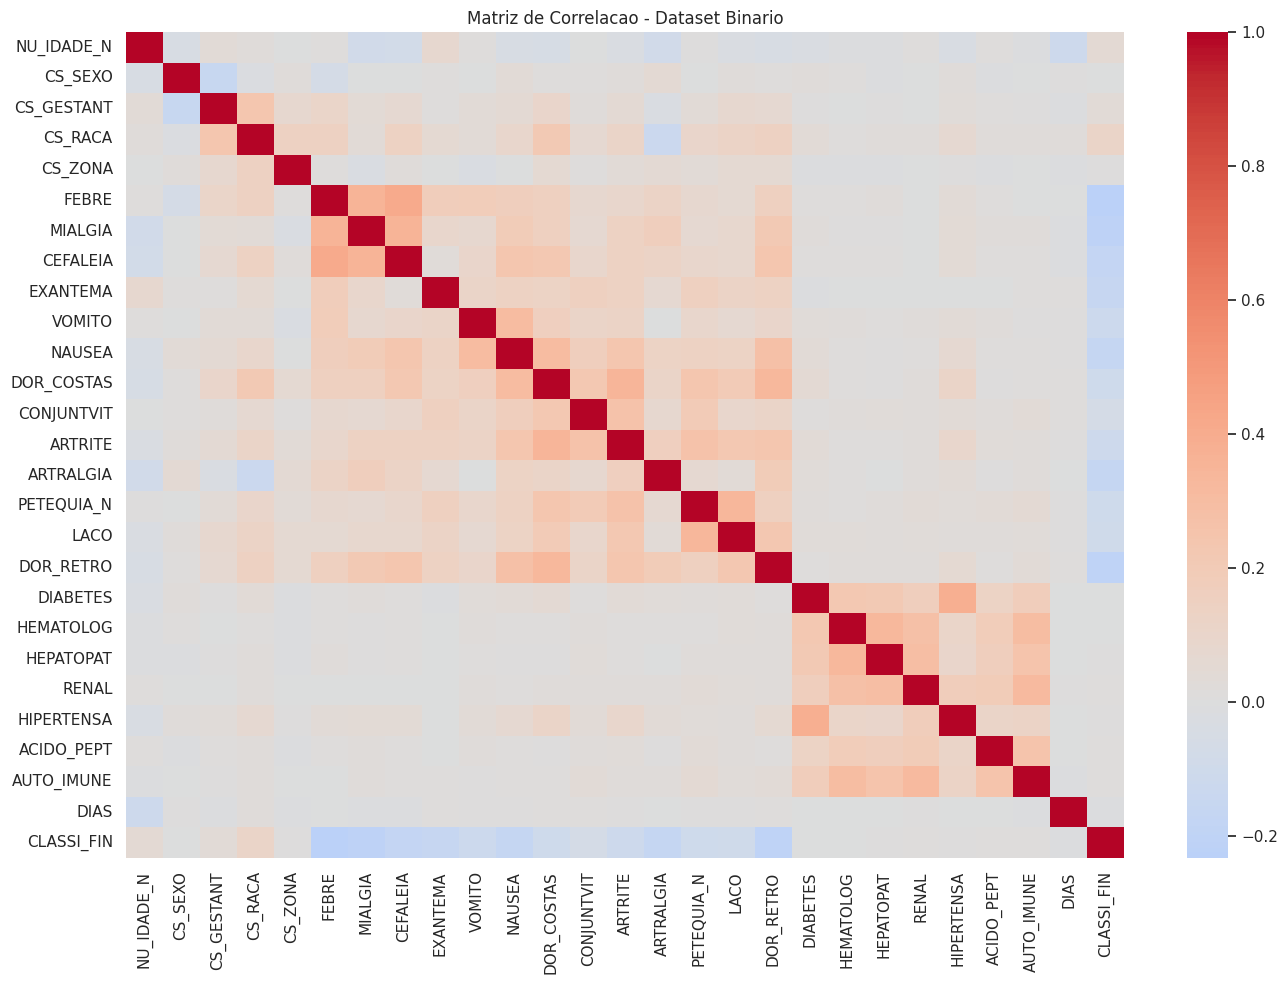

In [5]:
# Mapa de calor para observar relacoes lineares entre atributos numericos.
plt.figure(figsize=(14, 10))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, cmap="coolwarm", center=0)
plt.title("Matriz de Correlacao - Dataset Binario")
plt.tight_layout()
plt.show()

## STEP 5: Prepare Features and Target

In [6]:
# Separamos atributos (X) e alvo (y) sem alterar valores do dataset final.
X = df.drop(columns=[TARGET_COL]).values
y = df[TARGET_COL].astype(int).values

classes = np.unique(y)
print("Detected classes:", classes)
if len(classes) != 2:
    raise ValueError(f"Expected exactly 2 classes, but found {len(classes)}: {classes}")
if set(classes.tolist()) != {0, 1}:
    raise ValueError("As classes esperadas para CLASSI_FIN sao exatamente 0 e 1.")

print("X shape:", X.shape)
print("y shape:", y.shape)

Detected classes: [0 1]
X shape: (11448, 26)
y shape: (11448,)


## STEP 6: Train/Test Split and Feature Scaling

In [7]:
# Split estratificado para manter proporcoes de classe no treino e teste.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Verificacao explicita das proporcoes por classe para garantir imparcialidade.
full_ratio = pd.Series(y).value_counts(normalize=True).sort_index()
train_ratio = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_ratio = pd.Series(y_test).value_counts(normalize=True).sort_index()

counts_df = pd.DataFrame(
    {
        "full_count": pd.Series(y).value_counts().sort_index(),
        "train_count": pd.Series(y_train).value_counts().sort_index(),
        "test_count": pd.Series(y_test).value_counts().sort_index(),
        "full_ratio": full_ratio,
        "train_ratio": train_ratio,
        "test_ratio": test_ratio,
    }
)

print("Distribuicao por classe apos split:")
display(counts_df)

# Tolerancia pequena para arredondamentos de contagem.
if not np.allclose(train_ratio.values, full_ratio.values, atol=1e-3):
    raise ValueError("Proporcao das classes no treino difere da base completa.")
if not np.allclose(test_ratio.values, full_ratio.values, atol=1e-3):
    raise ValueError("Proporcao das classes no teste difere da base completa.")

# O scaler e ajustado apenas no treino para evitar leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_test shape:", y_test.shape)

Distribuicao por classe apos split:


,full_count,train_count,test_count,full_ratio,train_ratio,test_ratio
0,5724,4579,1145,0.5,0.5,0.5
1,5724,4579,1145,0.5,0.5,0.5


X_train shape: (9158, 26)
y_train shape: (9158,)
X_test shape: (2290, 26)
y_test shape: (2290,)


## STEP 7: Build and Compile Binary Model

In [8]:
# Arquitetura base para classificacao binaria.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

W0000 00:00:1779564941.401452   11505 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1779564941.573861   11505 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

## STEP 8: Train Model

In [9]:
# Early stopping reduz risco de overfitting em treinos longos.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=120,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/120


I0000 00:00:1779564943.043439   11660 service.cc:153] XLA service 0x7f2be8030250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779564943.043474   11660 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.3.0)
I0000 00:00:1779564943.066403   11660 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779564943.174274   11660 cuda_dnn.cc:461] Loaded cuDNN version 90300
I0000 00:00:1779564943.208927   11660 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1524__.11
I0000 00:00:1779564944.230789   11660 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.

 85/229 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5602 - loss: 0.6876

I0000 00:00:1779564947.243203   11660 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


225/229 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5986 - loss: 0.6674

I0000 00:00:1779564947.777409   11662 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1524__.11
I0000 00:00:1779564948.006152   11662 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779564948.201670   11880 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1779564948.473498   11885 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1779564948.888296   11662 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a 

229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5993 - loss: 0.6669

I0000 00:00:1779564950.741467   11660 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779564951.100247   12047 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 272 bytes spill stores, 272 bytes spill loads

I0000 00:00:1779564951.280174   12043 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 84 bytes spill stores, 84 bytes spill loads

I0000 00:00:1779564951.464340   12050 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 84 bytes spill stores, 84 bytes spill loads



229/229 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6396 - loss: 0.6417 - val_accuracy: 0.6927 - val_loss: 0.5958
Epoch 2/120
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6653 - loss: 0.6140 - val_accuracy: 0.7003 - val_loss: 0.5937
Epoch 3/120
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6794 - loss: 0.6082 - val_accuracy: 0.6971 - val_loss: 0.5876
Epoch 4/120
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6832 - loss: 0.5998 - val_accuracy: 0.6976 - val_loss: 0.5846
Epoch 5/120
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6821 - loss: 0.5940 - val_accuracy: 0.6987 - val_loss: 0.5864
Epoch 6/120
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6929 - loss: 0.5898 - val_accuracy: 0.6960 - val_loss: 0.5833
Epoch 7/120
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6918 - loss: 0.5886 - val_accuracy: 0.7020 - val_loss: 0.5830
Epoch 8/120
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6877 - loss: 0.5866 - val_accuracy: 0.69

## STEP 9: Evaluate Accuracy and Classification Metrics

I0000 00:00:1779564967.374691   11660 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779564967.703798   13410 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 84 bytes spill stores, 84 bytes spill loads

I0000 00:00:1779564967.938761   13403 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 272 bytes spill stores, 272 bytes spill loads

I0000 00:00:1779564968.004744   13409 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 84 bytes spill stores, 84 bytes spill loads

I0000 00:00:1779564968.030532   13403 subprocess_compilation.cc:348] ptxas warning : Registers are spill

Test loss: 0.5872
Test accuracy: 0.6825

Accuracy (sklearn): 0.6825


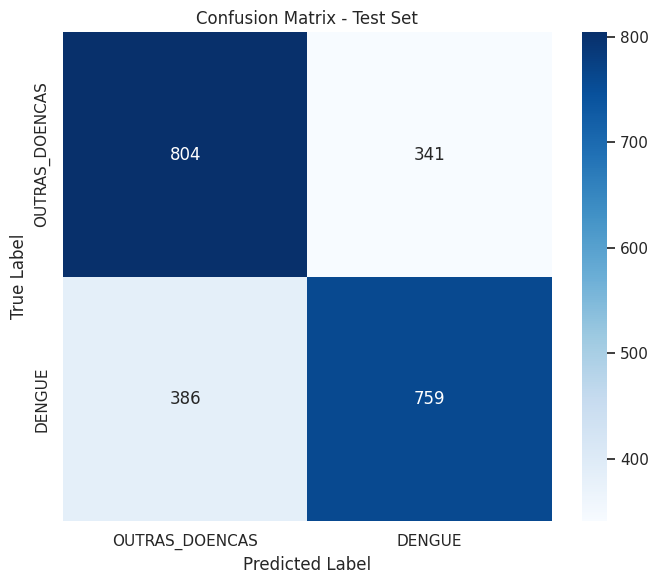


Classification Report:
                precision    recall  f1-score   support

OUTRAS_DOENCAS     0.6756    0.7022    0.6887      1145
        DENGUE     0.6900    0.6629    0.6762      1145

      accuracy                         0.6825      2290
     macro avg     0.6828    0.6825    0.6824      2290
  weighted avg     0.6828    0.6825    0.6824      2290



In [10]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Predicao final com limiar de 0.5 sobre probabilidades da sigmoid.
probs = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (probs >= 0.5).astype(int)

print("\nAccuracy (sklearn):", f"{accuracy_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[CLASS_NAME_MAP[i] for i in sorted(CLASS_NAME_MAP)],
    yticklabels=[CLASS_NAME_MAP[i] for i in sorted(CLASS_NAME_MAP)],
)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[CLASS_NAME_MAP[i] for i in sorted(CLASS_NAME_MAP)],
        digits=4,
    )
)

## STEP 10: Training Curves (Loss and Accuracy)

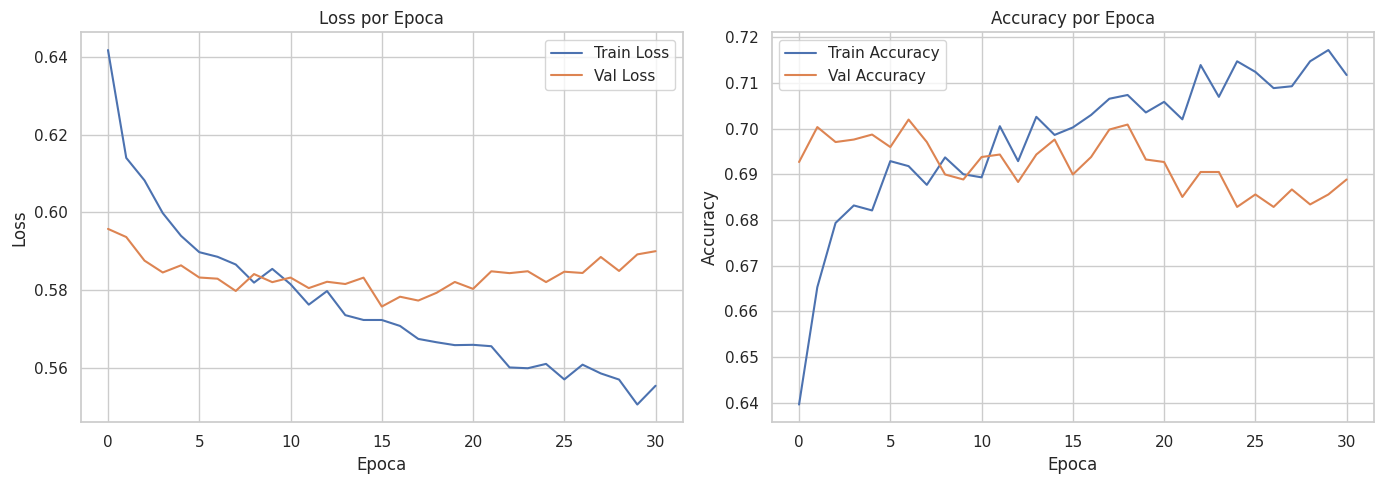

In [11]:
# Curvas de treino e validacao para analisar convergencia e overfitting.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss por Epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy por Epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()